In [1]:
from pathlib import Path
import pandas as pd

project_root = Path.cwd().parent
data_path = project_root / "outputs"

df = pd.read_csv(data_path / "london_features_dataset.csv")

print(df.head())
print(df.shape)
print(df.columns.tolist())

   count_point_id direction_of_travel  count_date  hour region_name  \
0            6000                   N  2000-03-27    10      London   
1            6000                   S  2000-03-27    10      London   
2            6000                   S  2000-03-27    11      London   
3            6000                   N  2000-03-27    11      London   
4            6000                   S  2000-03-27    12      London   

  local_authority_name road_name road_category road_type   latitude  ...  \
0               Barnet        M1            TM     Major  51.587522  ...   
1               Barnet        M1            TM     Major  51.587522  ...   
2               Barnet        M1            TM     Major  51.587522  ...   
3               Barnet        M1            TM     Major  51.587522  ...   
4               Barnet        M1            TM     Major  51.587522  ...   

             timestamp  hour_of_day  day_of_week  month  year  day   lag_1  \
0  2000-03-27 10:00:00           10   

In [2]:
print(df[["count_point_id", "latitude", "longitude", "all_motor_vehicles"]].head())

   count_point_id   latitude  longitude  all_motor_vehicles
0            6000  51.587522  -0.237927               853.0
1            6000  51.587522  -0.237927              1633.0
2            6000  51.587522  -0.237927              1305.0
3            6000  51.587522  -0.237927               994.0
4            6000  51.587522  -0.237927              1179.0


In [3]:
hotspot_df = df[["count_point_id", "latitude", "longitude", "all_motor_vehicles"]].copy()

print(hotspot_df.head())
print(hotspot_df.isnull().sum())

   count_point_id   latitude  longitude  all_motor_vehicles
0            6000  51.587522  -0.237927               853.0
1            6000  51.587522  -0.237927              1633.0
2            6000  51.587522  -0.237927              1305.0
3            6000  51.587522  -0.237927               994.0
4            6000  51.587522  -0.237927              1179.0
count_point_id        0
latitude              0
longitude             0
all_motor_vehicles    0
dtype: int64


In [4]:
hotspot_df = hotspot_df.dropna(subset=["latitude", "longitude", "all_motor_vehicles"]).copy()

print(hotspot_df.shape)

(221381, 4)


In [5]:
threshold = hotspot_df["all_motor_vehicles"].quantile(0.90)
print("Hotspot threshold:", threshold)

high_traffic_df = hotspot_df[hotspot_df["all_motor_vehicles"] >= threshold].copy()

print(high_traffic_df.shape)
print(high_traffic_df.head())

Hotspot threshold: 2645.0
(22163, 4)
     count_point_id   latitude  longitude  all_motor_vehicles
18             6000  51.587522  -0.237927              3620.0
40             6000  51.587522  -0.237927              2757.0
42             6000  51.587522  -0.237927              2948.0
90             6000  51.587522  -0.237927              2924.0
114            6000  51.587522  -0.237927              2883.0


In [6]:
high_traffic_points = high_traffic_df.groupby("count_point_id").agg({
    "latitude": "first",
    "longitude": "first",
    "all_motor_vehicles": "mean"
}).reset_index()

print(high_traffic_points.head())
print(high_traffic_points.shape)

   count_point_id   latitude  longitude  all_motor_vehicles
0            6000  51.587522  -0.237927         2909.400000
1            6001  51.634689  -0.265292         3399.886076
2            6013  51.494066  -0.432702         4224.479839
3            6071  51.518228  -0.009839         3048.492537
4            6076  51.589080  -0.204232         3494.142322
(196, 4)


In [7]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

coords = high_traffic_points[["latitude", "longitude"]]

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

dbscan = DBSCAN(eps=0.3, min_samples=3)
clusters = dbscan.fit_predict(coords_scaled)

high_traffic_points["cluster"] = clusters

print(high_traffic_points.head())
print(high_traffic_points["cluster"].value_counts())

   count_point_id   latitude  longitude  all_motor_vehicles  cluster
0            6000  51.587522  -0.237927         2909.400000        0
1            6001  51.634689  -0.265292         3399.886076        0
2            6013  51.494066  -0.432702         4224.479839        0
3            6071  51.518228  -0.009839         3048.492537        0
4            6076  51.589080  -0.204232         3494.142322        0
cluster
 0    152
 2      8
-1      8
 4      8
 5      8
 6      5
 1      4
 3      3
Name: count, dtype: int64


In [8]:
hotspots_only = high_traffic_points[high_traffic_points["cluster"] != -1].copy()

print(hotspots_only.head())
print("Number of hotspot points:", len(hotspots_only))
print("Number of hotspot clusters:", hotspots_only["cluster"].nunique())

   count_point_id   latitude  longitude  all_motor_vehicles  cluster
0            6000  51.587522  -0.237927         2909.400000        0
1            6001  51.634689  -0.265292         3399.886076        0
2            6013  51.494066  -0.432702         4224.479839        0
3            6071  51.518228  -0.009839         3048.492537        0
4            6076  51.589080  -0.204232         3494.142322        0
Number of hotspot points: 188
Number of hotspot clusters: 7


In [9]:
hotspot_summary = hotspots_only.groupby("cluster").agg({
    "count_point_id": "count",
    "all_motor_vehicles": "mean",
    "latitude": "mean",
    "longitude": "mean"
}).rename(columns={
    "count_point_id": "num_points",
    "all_motor_vehicles": "avg_traffic"
}).reset_index()

print(hotspot_summary)

   cluster  num_points  avg_traffic   latitude  longitude
0        0         152  3187.568349  51.531083  -0.159800
1        1           4  2969.616111  51.430421  -0.397692
2        2           8  3488.693680  51.387544  -0.268729
3        3           3  3418.670015  51.679343  -0.054423
4        4           8  2945.742674  51.453162  -0.210109
5        5           8  3006.640625  51.411219  -0.306192
6        6           5  3385.728508  51.584327   0.221063


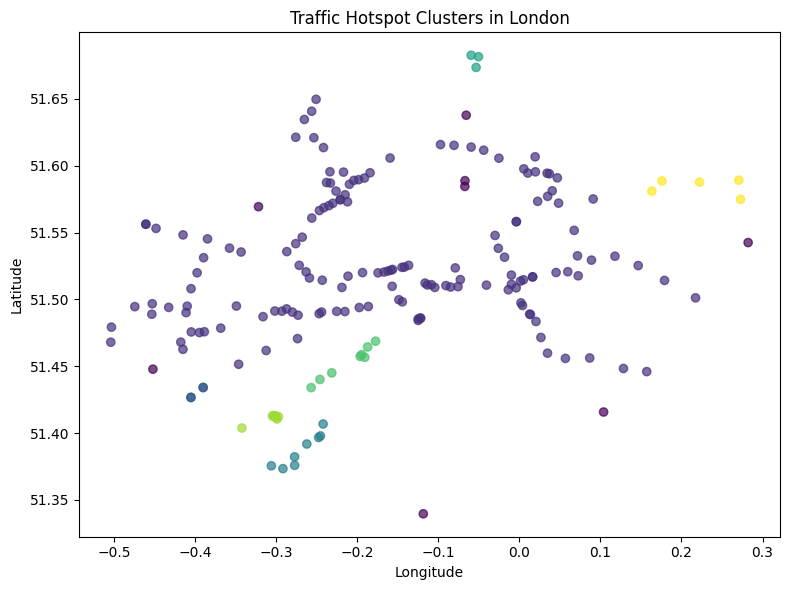

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    high_traffic_points["longitude"],
    high_traffic_points["latitude"],
    c=high_traffic_points["cluster"],
    alpha=0.7
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Traffic Hotspot Clusters in London")
plt.tight_layout()
plt.show()

In [11]:
from pathlib import Path

output_path = Path("../outputs")
output_path.mkdir(exist_ok=True)

high_traffic_points.to_csv(output_path / "hotspot_points.csv", index=False)
hotspot_summary.to_csv(output_path / "hotspot_summary.csv", index=False)

print("Hotspot outputs saved.")

Hotspot outputs saved.


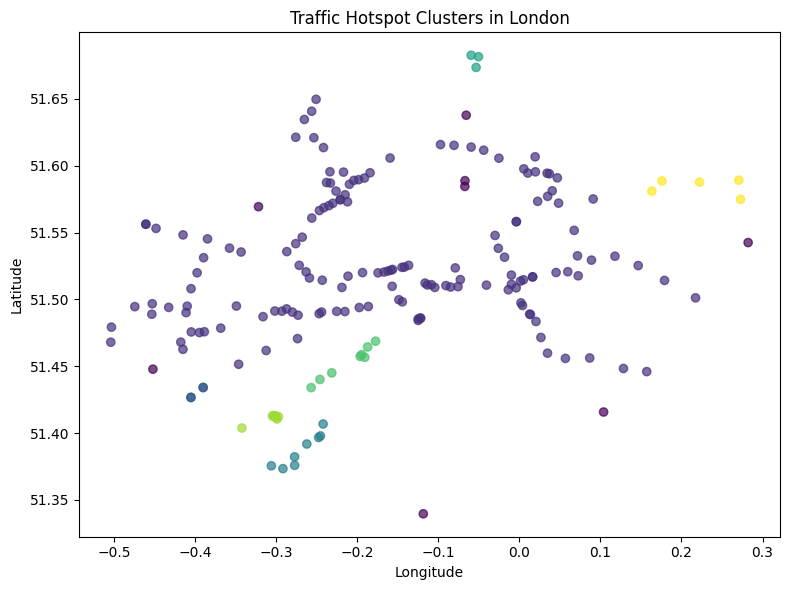

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(
    high_traffic_points["longitude"],
    high_traffic_points["latitude"],
    c=high_traffic_points["cluster"],
    alpha=0.7
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Traffic Hotspot Clusters in London")
plt.tight_layout()
plt.savefig(output_path / "hotspot_clusters.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
hotspot_summary = hotspot_summary.sort_values("num_points", ascending=False).reset_index(drop=True)
print(hotspot_summary)

   cluster  num_points  avg_traffic   latitude  longitude
0        0         152  3187.568349  51.531083  -0.159800
1        2           8  3488.693680  51.387544  -0.268729
2        4           8  2945.742674  51.453162  -0.210109
3        5           8  3006.640625  51.411219  -0.306192
4        6           5  3385.728508  51.584327   0.221063
5        1           4  2969.616111  51.430421  -0.397692
6        3           3  3418.670015  51.679343  -0.054423
